<a href="https://colab.research.google.com/github/aboettcher-sig/morocco-forests-sig/blob/main/scripts/utility/pull_gee_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import pandas as pd
import geopandas as gpd
from google.colab import userdata
cloud_project = userdata.get('cloud_project')

ee.Authenticate()
ee.Initialize(project = cloud_project)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Helper functions

In [ ]:
import ee

def export_gee_dataset(dataset_id, aoi, start_date, end_date, filename_prefix, folder='GEE_Exports', export_format="GeoTIFF"):
    """
    Export all images inside an AOI from a GEE dataset for a given time range.

    Parameters:
    - dataset_id: str -> The GEE dataset ID (e.g., "LANDSAT/LC08/C02/T1_L2", "COPERNICUS/S2_SR").
    - aoi: ee.Geometry -> The area of interest (Polygon, Rectangle, etc.).
    - start_date: str -> The start date (YYYY-MM-DD).
    - end_date: str -> The end date (YYYY-MM-DD).
    - filename_prefix: str -> Prefix for the exported file names.
    - folder: str -> Folder in Google Drive where the export will be saved.
    - export_format: str -> Choose "GeoTIFF" (for raster) or "CSV" (for tabular).
    """
    try:
        # Load ImageCollection and filter by date and AOI
        collection = ee.ImageCollection(dataset_id).filterBounds(aoi).filterDate(ee.Date(start_date), ee.Date(end_date))

        if export_format == "GeoTIFF":
            # Export each image in the collection individually
            image_list = collection.toList(collection.size())  # Convert to list (server-side)
            count = image_list.size().getInfo()  # Get the number of images (client-side call)
            print(f"Exporting {count} images from {dataset_id}...")

            for i in range(count):
                image = ee.Image(image_list.get(i))
                image_id = image.get("system:index").getInfo()  # Unique image identifier
                export_filename = f"{filename_prefix}_{image_id}"

                export_task = ee.batch.Export.image.toDrive(
                    image=image.clip(aoi),  # Clip to AOI
                    description=export_filename,
                    folder=folder,
                    fileNamePrefix=export_filename,
                    fileFormat="GeoTIFF",
                    region=aoi,
                    maxPixels=1e13
                )
                export_task.start()
                print(f"Started export for {dataset_id}: {export_filename} ({export_format})")

        elif export_format == "CSV":
            # Function to sample all bands at native resolution
            def extract_pixels(image):
                sampled = image.sampleRegions(
                    collection=aoi,  # Uses AOI as sampling region
                    geometries=True  # Keeps lat/lon information
                )
                return sampled

            # Apply extraction function to the entire collection and flatten results
            sampled_fc = collection.map(extract_pixels).flatten()

            export_task = ee.batch.Export.table.toDrive(
                collection=sampled_fc,
                description=filename_prefix,
                folder=folder,
                fileNamePrefix=filename_prefix,
                fileFormat="CSV"
            )
            export_task.start()
            print(f"Started export for {dataset_id}: {filename_prefix} (CSV)")

        else:
            raise ValueError("Invalid export format. Choose 'GeoTIFF' or 'CSV'.")

    except Exception as e:
        print(f"Failed to process dataset {dataset_id}: {e}")

In [ ]:
import ee

def export_gee_image(image_id, aoi, filename_prefix, folder='GEE_Exports', export_format="CSV"):
    """
    Export a single GEE image inside an AOI.

    Parameters:
    - image_id: str -> The GEE image ID (e.g., "USGS/3DEP/10m").
    - aoi: ee.Geometry -> The area of interest (Polygon, Rectangle, etc.).
    - filename_prefix: str -> Prefix for the exported file name.
    - folder: str -> Folder in Google Drive where the export will be saved.
    - export_format: str -> Choose "GeoTIFF" (for raster) or "CSV" (for tabular).
    """
    try:

      image = ee.Image(image_id)  # Convert string to ee.Image object

      export_filename = f"{filename_prefix}_single"

      if export_format == "GeoTIFF":
          ee.batch.Export.image.toDrive(
              image=image.clip(aoi),
              description=export_filename,
              folder=folder,
              fileNamePrefix=export_filename,
              fileFormat="GeoTIFF",
              region=aoi,
              maxPixels=1e13
          ).start()

      elif export_format == "CSV":
          ee.batch.Export.table.toDrive(
              collection=image.sampleRegions(
                  collection=aoi,
                  geometries=True
              ),
              description=export_filename,
              folder=folder,
              fileNamePrefix=export_filename,
              fileFormat="CSV"
          ).start()

      else:
          raise ValueError("Invalid export format. Choose 'GeoTIFF' or 'CSV'.")

      print(f"Started export: {export_filename} ({export_format})")

    except Exception as e:
        print(f"Failed to process dataset {image_id}: {e}")

In [ ]:
import ee


def build_aoi(gdf, pixel_size):
    """Buffer gdf by pixel_size*3 (in UTM), reproject back to WGS84, and return an
    ee.FeatureCollection. The buffer guarantees sampleRegions returns at least one
    pixel of a dataset with the given native pixel_size (in meters)."""
    buffered = gdf.copy()
    buffered['geometry'] = buffered.to_crs(gdf.estimate_utm_crs()).buffer(pixel_size * 3).to_crs('EPSG:4326')
    return ee.FeatureCollection(
        [ee.Feature(ee.Geometry(geom.__geo_interface__)) for geom in buffered['geometry']]
    )

# Specify data

GeoPackage with bounding box saved at /content/drive/MyDrive/morroco_forests/test_region.gpkg


<Axes: >

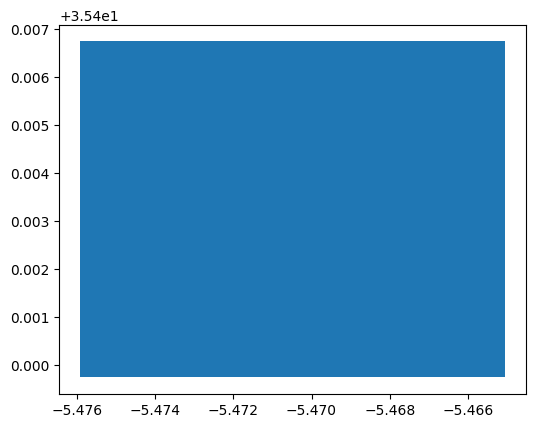

In [ ]:
#If you want to get all the data over a specific area, for inference.
import geopandas as gpd
from shapely.geometry import Polygon
import os
import time

# Define the bounding box coordinates
minx, miny, maxx, maxy =  -5.475904 , 35.399737, -5.465059, 35.406735

# Create a Polygon from the bounding box coordinates
bbox_polygon = Polygon([(minx, miny), (minx, maxy), (maxx, maxy), (maxx, miny), (minx, miny)])

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame([{'geometry': bbox_polygon}], crs="EPSG:4326")

# Specify the output path for the GeoPackage
output_path = "/content/drive/MyDrive/morroco_forests/test_region.gpkg"


# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_dir = os.path.dirname(output_path)

# Save the GeoDataFrame to a GeoPackage
gdf.to_file(output_path, driver="GPKG")

print(f"GeoPackage with bounding box saved at {output_path}")

gdf.plot()

In [ ]:
# Output / naming
output_dir = "/content/drive/MyDrive/morroco_forests"
run_name = "morroco_forest_exploration_2026_08_18_1600"

export_dir = os.path.join(output_dir, run_name)
export_folder = run_name
export_prefix = run_name

# Create the Drive export folder and confirm it's visible BEFORE any export
# starts. GEE creates the folder itself when it can't see one, so tasks firing
# against a not-yet-synced folder spawn duplicates; block until it's there.
os.makedirs(export_dir, exist_ok=True)
while not os.path.isdir(export_dir):
    time.sleep(1)
print(f"Confirmed export folder: {export_dir}")

# Dates -- defined once here and reused below
ts_start_year = 1984          # spectral time-series first year (inclusive)
ts_end_year   = 2028          # spectral time-series last year (inclusive)
archive_end   = "2028-12-31"  # end date for full-archive pulls (TerraClimate, Dynamic World)

# Pull Spectral data

In [ ]:
# Spectral time series: one buffered AOI (Landsat-sized 30 m pixels), looped over
# each collection and each year window. Sentinel-2 (10 m) samples fine inside the
# same buffer. Add or remove sensors by editing the datasets dict.
aoi = build_aoi(gdf, pixel_size=30)

spectral_datasets = {
    "Landsat9":  "LANDSAT/LC09/C02/T1_L2",
    "Landsat8":  "LANDSAT/LC08/C02/T1_L2",
    "Landsat7":  "LANDSAT/LE07/C02/T1_L2",
    "Landsat5":  "LANDSAT/LT05/C02/T1_L2",
    "Sentinel2": "COPERNICUS/S2_SR_HARMONIZED",
    "Sentinel1": "COPERNICUS/S1_GRD",
}

for name, dataset_id in spectral_datasets.items():
    i_prior = ts_start_year
    for i in range(ts_start_year, ts_end_year + 1):
        print([name, i_prior, i])
        export_gee_dataset(
            dataset_id=dataset_id,
            aoi=aoi,
            start_date=f"{i_prior}-01-01",
            end_date=f"{i}-12-31",
            filename_prefix=f"{name}_{export_prefix}_{i_prior}_{i}",
            export_format="CSV",
            folder=export_folder,
        )
        i_prior = i

# Pull Terrain data

In [ ]:
# SRTM mTPI (~270 m)
aoi = build_aoi(gdf, pixel_size=270)
export_gee_image(
    "CSP/ERGo/1_0/Global/SRTM_mTPI",
    aoi,
    f"SRTM_mTPI_{export_prefix}",
    folder=export_folder,
    export_format="CSV",
)

In [ ]:
# Terrain: elevation from MERIT DEM (the DEM Geomorpho90m is derived from) with
# Geomorpho90m's precomputed slope and aspect. All three are global at ~90 m, so
# they replace the US-only 3DEP source. The Geomorpho90m layers are tiled
# ImageCollections, so mosaic each to one image and rename its band so the
# exported column is meaningful.
aoi = build_aoi(gdf, pixel_size=90)

elevation = ee.Image("MERIT/DEM/v1_0_3").select("dem").rename("elevation")
slope = ee.ImageCollection("projects/sat-io/open-datasets/Geomorpho90m/slope").filterBounds(aoi).mosaic().rename("slope")
aspect = ee.ImageCollection("projects/sat-io/open-datasets/Geomorpho90m/aspect").filterBounds(aoi).mosaic().rename("aspect")

terrain_layers = {"elevation": elevation, "slope": slope, "aspect": aspect}

# mosaic() drops the source projection, so sampleRegions would default to a 1-degree
# grid and return nothing over a small AOI. Sample at the native 90 m scale so
# slope/aspect are picked up; elevation is a native image and is unaffected.
for key, img in terrain_layers.items():
    export_filename = f"Terrain_{export_prefix}_{key}"
    ee.batch.Export.table.toDrive(
        collection=img.sampleRegions(collection=aoi, geometries=True, scale=90),
        description=export_filename,
        folder=export_folder,
        fileNamePrefix=export_filename,
        fileFormat="CSV"
    ).start()
    print(f"Started export: {export_filename} (CSV)")

In [ ]:
# TerraClimate (~4638 m), full archive
aoi = build_aoi(gdf, pixel_size=4638)
export_gee_dataset(
    dataset_id="IDAHO_EPSCOR/TERRACLIMATE",
    aoi=aoi,
    start_date="1985-01-01",
    end_date=archive_end,
    filename_prefix=f"TerraClimate_{export_prefix}",
    export_format="CSV",
    folder=export_folder,
)

In [ ]:
# CFSv2 (~22 km, 6-hourly), full archive -- climate coverage past TerraClimate,
# which ends in 2025. Harmonized collection (plain FOR6H is deprecated);
# temperature bands are in Kelvin.
aoi = build_aoi(gdf, pixel_size=22264)
export_gee_dataset(
    dataset_id="NOAA/CFSV2/FOR6H_HARMONIZED",
    aoi=aoi,
    start_date="1979-01-01",
    end_date=archive_end,
    filename_prefix=f"CFSv2_{export_prefix}",
    export_format="CSV",
    folder=export_folder,
)

# Pull Model data

In [ ]:
# Spectral time series: one buffered AOI (Landsat-sized 30 m pixels), looped over
# each collection and each year window. Sentinel-2 (10 m) samples fine inside the
# same buffer. Add or remove sensors by editing the datasets dict.
aoi = build_aoi(gdf, pixel_size=30)

model_datasets = {
    "DynamicWorld": "GOOGLE/DYNAMICWORLD/V1"
}

for name, dataset_id in model_datasets.items():
    i_prior = ts_start_year
    for i in range(ts_start_year, ts_end_year + 1):
        print([name, i_prior, i])
        export_gee_dataset(
            dataset_id=dataset_id,
            aoi=aoi,
            start_date=f"{i_prior}-01-01",
            end_date=f"{i}-12-31",
            filename_prefix=f"{name}_{export_prefix}_{i_prior}_{i}",
            export_format="CSV",
            folder=export_folder,
        )
        i_prior = i